#### Import pandas and matplotlib

In [590]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


#### Read CSV file

In [591]:
df = pd.read_csv('bmw.csv')

**Make columns lower names case and strip off white spaces to avoid errors**

In [592]:
df.columns = df.columns.str.lower().str.strip()

**Remove unwanted columns**

In [593]:
df = df.drop(columns=[
    'unnamed: 12',
    'unnamed: 13',
    'unnamed: 14',
    'unnamed: 15',
    'unnamed: 16'
    ])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   model                 50000 non-null  str    
 1   year                  50000 non-null  int64  
 2   region                50000 non-null  str    
 3   color                 50000 non-null  str    
 4   fuel_type             50000 non-null  str    
 5   transmission          50000 non-null  str    
 6   engine_size_l         50000 non-null  float64
 7   mileage_km            50000 non-null  str    
 8   price_usd             50000 non-null  str    
 9   sales_volume          50000 non-null  int64  
 10  revenue               50000 non-null  str    
 11  sales_classification  50000 non-null  str    
dtypes: float64(1), int64(2), str(9)
memory usage: 4.6 MB


**Remove Extra white spaces from all columns**

In [594]:

df.select_dtypes(include=['object', 'string']).apply(lambda x: x.str.strip())


,model,region,color,fuel_type,transmission,mileage_km,price_usd,revenue,sales_classification
0,5 Series,Asia,Red,Petrol,Manual,"151,748.00","$98,740.00","$819,542,000.00",High
1,i8,North America,Red,Hybrid,Automatic,"121,671.00","$79,219.00","$271,562,732.00",Low
2,5 Series,North America,Blue,Petrol,Automatic,"10,991.00","$113,265.00","$792,175,410.00",Low
3,X3,Middle East,Blue,Petrol,Automatic,"27,255.00","$60,971.00","$246,749,637.00",Low
4,7 Series,South America,Black,Diesel,Manual,"122,131.00","$49,898.00","$153,685,840.00",Low
...,...,...,...,...,...,...,...,...,...
49995,i3,Asia,Red,Hybrid,Manual,"151,030.00","$42,932.00","$351,269,624.00",High
49996,i3,Middle East,Silver,Electric,Manual,"147,396.00","$48,714.00","$478,176,624.00",High
49997,5 Series,Middle East,Red,Petrol,Automatic,"174,939.00","$46,126.00","$381,923,280.00",High
49998,i3,Asia,White,Electric,Automatic,"3,379.00","$58,566.00","$555,557,076.00",High


**Clean up the Price column. remove the dollar sign, remove the .00 at the end, remove coma and convert to string**

In [595]:
#create a function for them all
def clean_ints(cols):
    df[cols] = df[cols].str.replace('.00', '').str.replace('$', '').str.replace(',', '')
    df[cols] = df[cols].astype(int)

    return df.head(2)


In [596]:
clean_ints('revenue')
clean_ints('price_usd')
clean_ints('mileage_km')

,model,year,region,color,fuel_type,transmission,engine_size_l,mileage_km,price_usd,sales_volume,revenue,sales_classification
0,5 Series,2016,Asia,Red,Petrol,Manual,3.5,151748,98740,8300,819542000,High
1,i8,2013,North America,Red,Hybrid,Automatic,1.6,121671,79219,3428,271562732,Low


In [597]:
chart_color = '#0543a6'

In [598]:
Total_revenue = df['revenue'].sum()
print(f'Total Revenue: {Total_revenue:,.2f} \n Nineteen trillion, twelve billion, two hundred forty-two million, five hundred thirty-four thousand, four hundred fifty-nine.\n')

#Total Sales
Total_sales = df['sales_volume'].sum()
print(f' Total Sales: {Total_sales:,.2f} \n Two hundred fifty-three million, three hundred seventy-five thousand, seven hundred thirty-four.')


Total Revenue: 19,012,242,534,459.00 
 Nineteen trillion, twelve billion, two hundred forty-two million, five hundred thirty-four thousand, four hundred fifty-nine.

 Total Sales: 253,375,734.00 
 Two hundred fifty-three million, three hundred seventy-five thousand, seven hundred thirty-four.


# MODELS

**Group Sales volume by models**

In [599]:
sales_grp = df.groupby('model')['sales_volume'].sum().reset_index().sort_values(by='sales_volume', ascending=False)
sales_grp


,model,sales_volume
2,7 Series,23786466
10,i8,23423891
5,X1,23406060
0,3 Series,23281303
9,i3,23133849
1,5 Series,23097519
4,M5,22779688
6,X3,22745529
7,X5,22709749
8,X6,22661986


**Group Revenue by Models**

In [600]:

revenue_grp = df.groupby('model')['revenue'].sum().reset_index().sort_values(by='revenue', ascending=False)
# revenue_grp['revenue'].apply(lambda x: f'{x:,.2f}')
revenue_grp


,model,revenue
2,7 Series,1790070249282
0,3 Series,1768534028214
10,i8,1764743448529
5,X1,1752985285361
1,5 Series,1735712423092
9,i3,1724197530210
7,X5,1708653383772
6,X3,1707951188482
4,M5,1698467355916
8,X6,1693423254979


**create two plots in same fig for revenue by models and Sales volume by models**

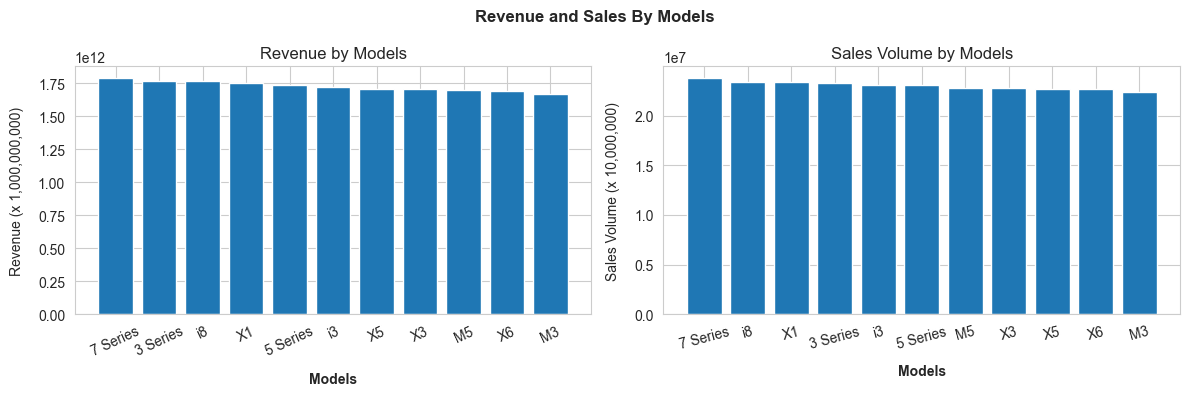

In [601]:
fig, ax = plt.subplots(1,2, figsize=(12,4))
fig.suptitle("Revenue and Sales By Models", fontweight='bold')
                       
ax[0].bar(revenue_grp['model'], revenue_grp['revenue'])
ax[0].set_title("Revenue by Models")
ax[0].set_ylabel("Revenue (x 1,000,000,000)", labelpad=10)
ax[0].tick_params(axis='x', rotation=25)
ax[0].set_xlabel("Models", labelpad=10, fontweight='bold')
ax[1].bar(sales_grp['model'], sales_grp['sales_volume'])
ax[1].set_title('Sales Volume by Models')
ax[1].tick_params(axis='x', rotation=15)
ax[1].set_xlabel("Models", labelpad=10, fontweight='bold')
ax[1].set_ylabel("Sales Volume (x 10,000,000)", labelpad=10)
fig.tight_layout()


In [602]:
#AVERAGE PRICE PER MODEL

model_price = df.groupby('model')['price_usd'].mean().reset_index().sort_values(by='price_usd', ascending=False)

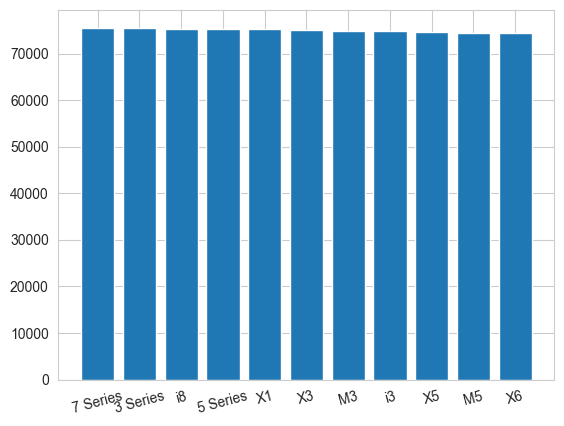

<Figure size 1000x400 with 0 Axes>

In [603]:

plt.bar(model_price['model'], model_price['price_usd'])
plt.xticks(rotation=15)
plt.figure(figsize=(10,4))
plt.tight_layout()
plt.show()

## YEAR BY YEAR ANALYSIS

In [604]:
yearly_trends = df.groupby('year')[['revenue', 'sales_volume']].sum().sort_values(by='revenue', ascending=False).reset_index()
yearly_trends['year'].astype(str)
yearly_trends



,year,revenue,sales_volume
0,2022,1344427738820,17920946
1,2024,1312808115466,17527854
2,2019,1289342744664,17191956
3,2016,1284641854435,16957550
4,2021,1272402559079,16884666
5,2014,1269989867142,16958960
6,2010,1261631480830,16933445
7,2011,1258944308614,16758941
8,2013,1258599026870,16866733
9,2012,1257840248199,16751895


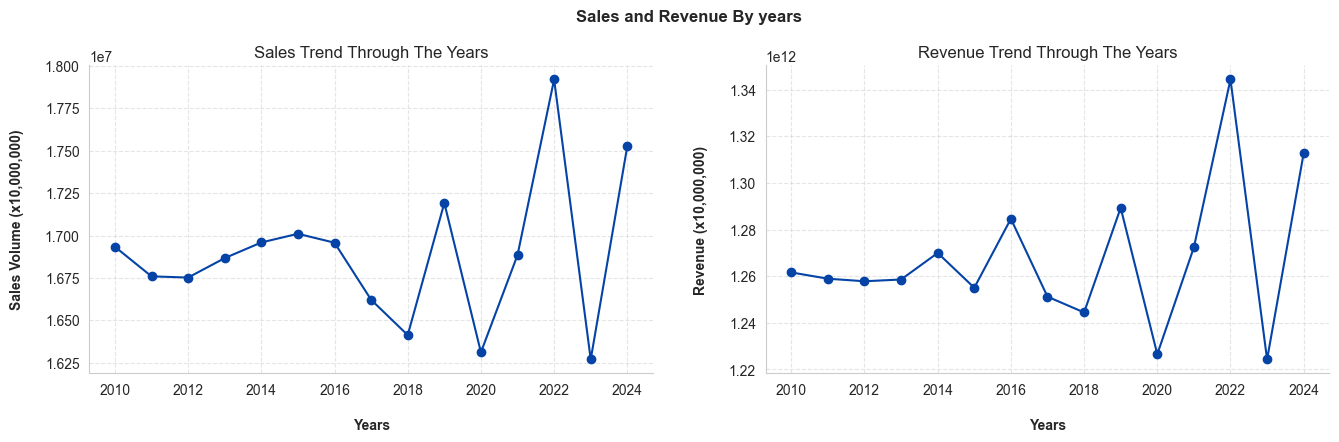

In [605]:
yearly_trends = yearly_trends.sort_values(by='year')
fig, ax = plt.subplots(1, 2, figsize=(16,4))
plt.suptitle('Sales and Revenue By years', fontweight='bold', y=1.02)

ax[1].plot(yearly_trends['year'], yearly_trends['revenue'],
           marker='o',
           linestyle='-',
           color=chart_color)

ax[0].plot(yearly_trends['year'], yearly_trends['sales_volume'], 
            marker='o',
           linestyle='-',
           color=chart_color)
ax[1].set_title('Revenue Trend Through The Years', fontname='arial')
ax[0].set_title('Sales Trend Through The Years', fontname='arial')


ax[0].set_ylabel("Sales Volume (x10,000,000)", labelpad=15, fontweight='bold')
ax[1].set_ylabel("Revenue (x10,000,000)", labelpad=15, fontweight='bold')

for chart in ax:
    chart.spines[['top','right']].set_visible(False)
    chart.grid(True, linestyle='--', alpha=0.5)
    chart.set_xlabel("Years", labelpad=15, fontweight='bold')
    chart.set_xlabel("Years", labelpad=15, fontweight='bold')
  
plt.show()

In [606]:
yearly_trends

,year,revenue,sales_volume
6,2010,1261631480830,16933445
7,2011,1258944308614,16758941
9,2012,1257840248199,16751895
8,2013,1258599026870,16866733
5,2014,1269989867142,16958960
10,2015,1255056528796,17010207
3,2016,1284641854435,16957550
11,2017,1251237076544,16620811
12,2018,1244465589591,16412273
2,2019,1289342744664,17191956


CHECKING YEAR ON YEAR REVENUE GROWTH

In [607]:
percentage_revenue_change = round((100 * (yearly_trends.iloc[-1]['revenue'] - yearly_trends.loc[0, 'revenue'])) / yearly_trends.loc[0, 'revenue'], 0)

print(f'Percentage difference between 2010 revenue and 2024 Revenue: {percentage_revenue_change}%')

Percentage difference between 2010 revenue and 2024 Revenue: -2.0%


In [608]:
yearly_trends['year'] = yearly_trends['year'].astype(int)
yearly_trends = yearly_trends.reset_index(drop=True)
yearly_trends['prev_yr_rev'] = yearly_trends['revenue'].shift(1)
yearly_trends = yearly_trends.fillna('0')
yearly_trends['prev_yr_rev'] = yearly_trends['prev_yr_rev'].astype(int)
yearly_trends['rev_growth'] = yearly_trends['revenue'] - yearly_trends['prev_yr_rev']
yearly_trends.loc[0, 'rev_growth'] = 0
yearly_trends['(%) Growth'] = round((100 * yearly_trends['rev_growth']) / yearly_trends['prev_yr_rev'], 2)

**Average growth of sales and Revenue**

In [609]:
yearly_trends

avg_growth = round(yearly_trends['(%) Growth'].mean(), 2)

print(f'Average growth all time: {avg_growth}%')

Average growth all time: 0.37%


In [610]:
yearly_trends

avg_growth_sales = round(yearly_trends['(%) Growth'].mean(), 2)

print(f'Average growth of Sales all time: {avg_growth_sales}%')

Average growth of Sales all time: 0.37%


In [611]:
yearly_trends


,year,revenue,sales_volume,prev_yr_rev,rev_growth,(%) Growth
0,2010,1261631480830,16933445,0,0,NaN
1,2011,1258944308614,16758941,1261631480830,-2687172216,-0.21
2,2012,1257840248199,16751895,1258944308614,-1104060415,-0.09
3,2013,1258599026870,16866733,1257840248199,758778671,0.06
4,2014,1269989867142,16958960,1258599026870,11390840272,0.91
5,2015,1255056528796,17010207,1269989867142,-14933338346,-1.18
6,2016,1284641854435,16957550,1255056528796,29585325639,2.36
7,2017,1251237076544,16620811,1284641854435,-33404777891,-2.60
8,2018,1244465589591,16412273,1251237076544,-6771486953,-0.54
9,2019,1289342744664,17191956,1244465589591,44877155073,3.61


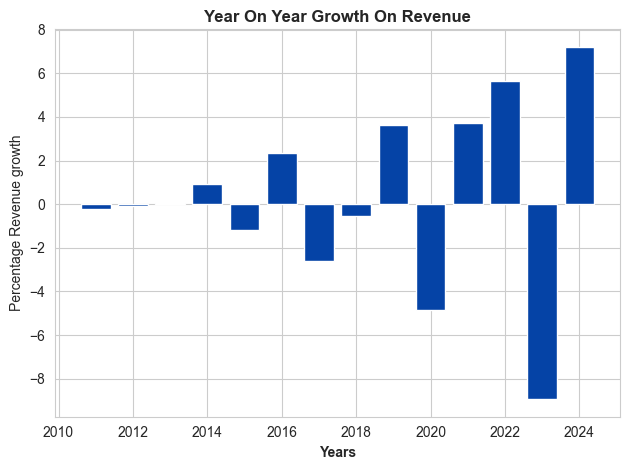

In [612]:
plt.bar(yearly_trends['year'], yearly_trends['(%) Growth'], color=chart_color)
plt.title("Year On Year Growth On Revenue",
          fontweight = 'bold',
          pad=5,
          fontname= 'Arial')
plt.xlabel('Years', fontweight='bold')
plt.ylabel('Percentage Revenue growth')
plt.tight_layout()
plt.show()

**Calculate Year on year Sales Growth**

In [613]:
yearly_trends['prev_yr_sales'] = yearly_trends['sales_volume'].shift(1)
yearly_trends['prev_yr_sales'] = yearly_trends['prev_yr_sales'].fillna(0)

yearly_trends['prev_yr_sales'] = yearly_trends['prev_yr_sales'].astype(int)
yearly_trends['sales_growth'] = yearly_trends['sales_volume'] - yearly_trends['prev_yr_sales']
yearly_trends.loc[0, 'sales_growth'] = 0
yearly_trends['pcnt Growth'] = round((100 * yearly_trends['sales_growth']) / yearly_trends['prev_yr_sales'], 2)

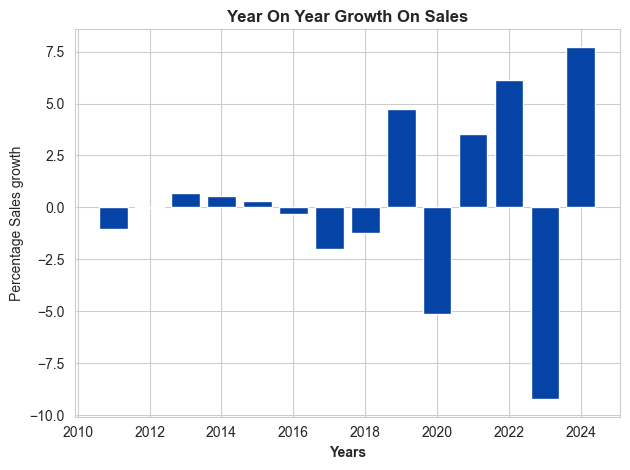

In [614]:
plt.bar(yearly_trends['year'], yearly_trends['pcnt Growth'], color=chart_color)
plt.title("Year On Year Growth On Sales",
          fontweight = 'bold',
          pad=5,
          fontname= 'Arial')
plt.xlabel('Years', fontweight='bold')
plt.ylabel('Percentage Sales growth')
plt.tight_layout()
plt.show()

## Regional Analysis

In [615]:
region_data = df.groupby('region')[['revenue', 'sales_volume']].sum().reset_index()
region_data

,region,revenue,sales_volume
0,Africa,3108999419352,41565252
1,Asia,3250635961348,42974277
2,Europe,3188079573212,42555138
3,Middle East,3167783530851,42326620
4,North America,3182938635076,42402629
5,South America,3113805414620,41551818


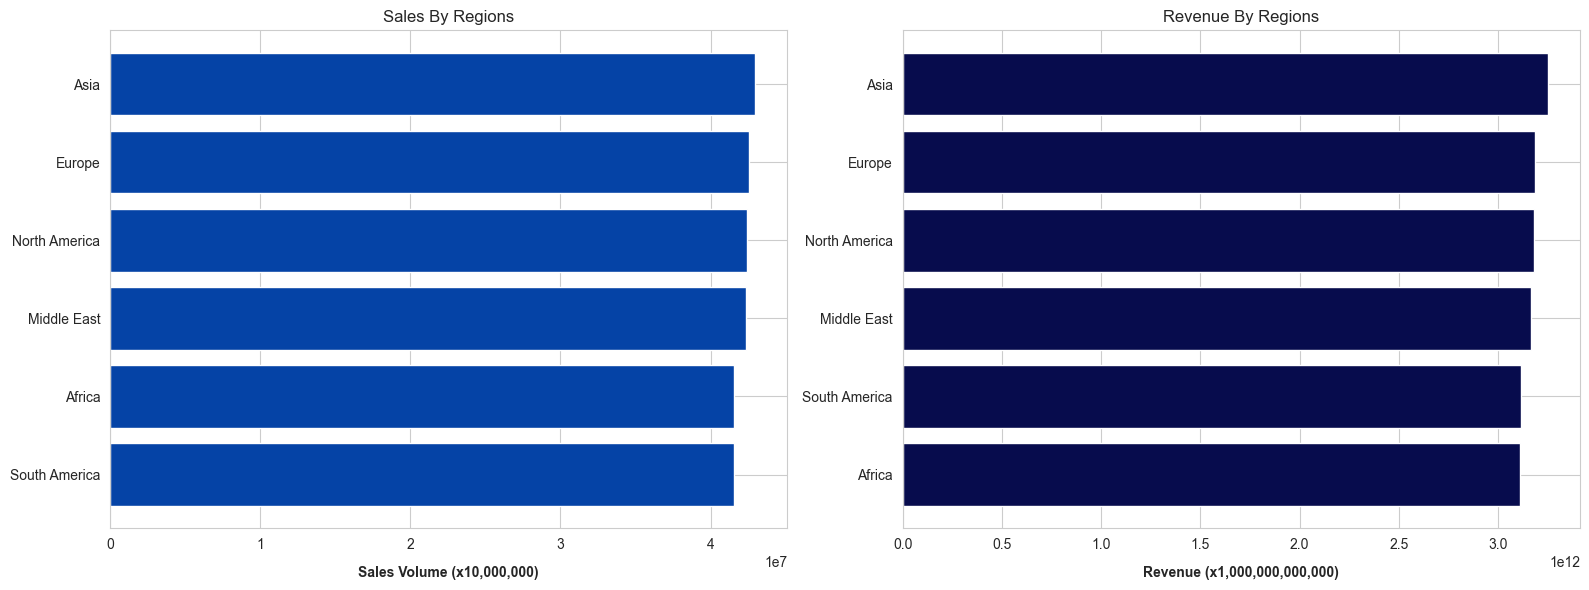

In [616]:
fig, ax = plt.subplots(1,2, figsize=(16,6))

region_data.sort_values(by='sales_volume', inplace=True)
ax[0].barh(region_data['region'], region_data['sales_volume'], color=chart_color)
region_data.sort_values(by='revenue', inplace=True)
ax[1].barh(region_data['region'], region_data['revenue'], color='#070c4d')
ax[1].set_title('Revenue By Regions')
ax[0].set_title('Sales By Regions')
ax[0].set_xlabel('Sales Volume (x10,000,000)', fontweight='bold', labelpad=10)
ax[1].set_xlabel('Revenue (x1,000,000,000,000)', fontweight='bold', labelpad=10)


plt.tight_layout()
plt.show()

In [617]:
region_data

,region,revenue,sales_volume
0,Africa,3108999419352,41565252
5,South America,3113805414620,41551818
3,Middle East,3167783530851,42326620
4,North America,3182938635076,42402629
2,Europe,3188079573212,42555138
1,Asia,3250635961348,42974277


In [618]:
region_data['total_revenue'] = region_data['revenue'].sum()
region_data['total_sales'] = region_data['sales_volume'].sum()

In [619]:

region_data

,region,revenue,sales_volume,total_revenue,total_sales
0,Africa,3108999419352,41565252,19012242534459,253375734
5,South America,3113805414620,41551818,19012242534459,253375734
3,Middle East,3167783530851,42326620,19012242534459,253375734
4,North America,3182938635076,42402629,19012242534459,253375734
2,Europe,3188079573212,42555138,19012242534459,253375734
1,Asia,3250635961348,42974277,19012242534459,253375734


**Calculate Percentage sales and Revenue Contribution per region**

In [620]:
region_data['percent_sales_contr'] = round((100 * region_data['sales_volume']/ region_data['total_sales']), 2)
region_data['percent_revenue_contr'] = round((100 * region_data['revenue']/ region_data['total_revenue']), 2)

In [621]:
region_data

,region,revenue,sales_volume,total_revenue,total_sales,percent_sales_contr,percent_revenue_contr
0,Africa,3108999419352,41565252,19012242534459,253375734,16.40,16.35
5,South America,3113805414620,41551818,19012242534459,253375734,16.40,16.38
3,Middle East,3167783530851,42326620,19012242534459,253375734,16.71,16.66
4,North America,3182938635076,42402629,19012242534459,253375734,16.74,16.74
2,Europe,3188079573212,42555138,19012242534459,253375734,16.80,16.77
1,Asia,3250635961348,42974277,19012242534459,253375734,16.96,17.10


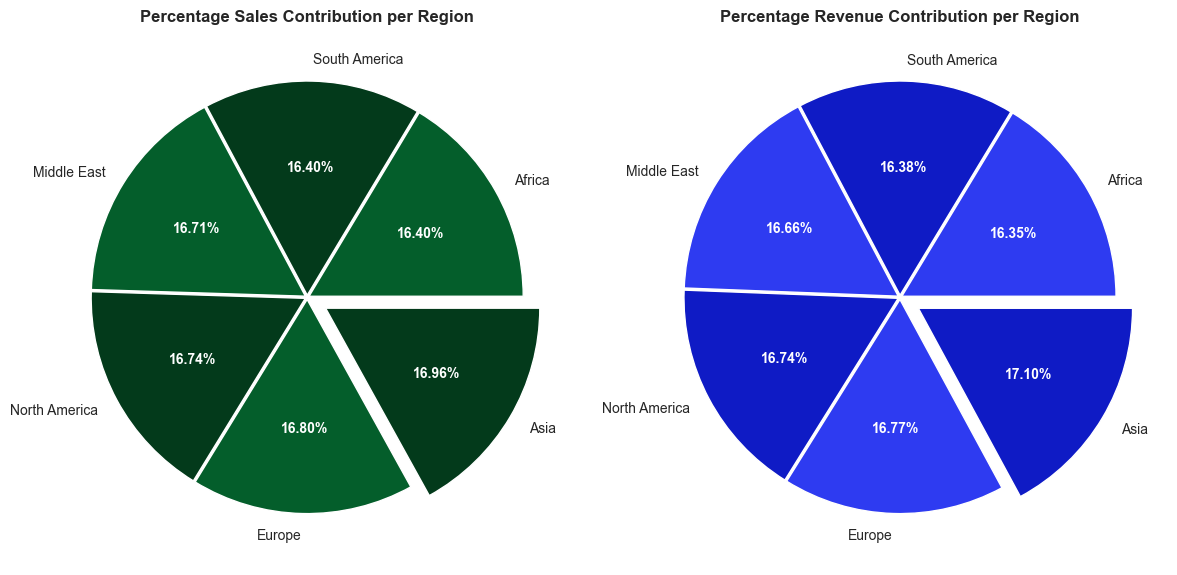

In [622]:
fig, ax = plt.subplots(1,2, figsize=(12,6))

ax[1].pie(region_data['percent_revenue_contr'], 
          autopct='%.2f%%', labels=region_data['region'],
            explode=[0.01,0.01,0.01,0.01,0.01,0.1],
          colors= ["#2e3bf1", "#0f1bc5"])

ax[0].pie(region_data['percent_sales_contr'],
           autopct='%.2f%%', labels=region_data['region'], 
           explode=[0.01,0.01,0.01,0.01,0.01,0.1],
           colors=["#045e2b", "#033a1b"])


for chart in ax:
    for text in chart.texts:  
        if '%' in text.get_text():      
            text.set_color('white')  
            text.set_fontweight('bold')    


ax[1].set_title('Percentage Revenue Contribution per Region', fontweight='bold')
ax[0].set_title('Percentage Sales Contribution per Region', fontweight='bold')
plt.tight_layout()
plt.show()

In [623]:
regions_years = df.groupby(['year', 'region'])['revenue'].sum().reset_index().sort_values(by=['region', 'region'])

regions_years.reset_index(drop=True, inplace=True)



regions_years['previous_year'] = regions_years.groupby('region')['revenue'].shift(1)
regions_years = regions_years.dropna()
regions_years['previous_year'] = regions_years['previous_year'].astype('Int64')
regions_years['growth_volume'] = regions_years['revenue'] - regions_years['previous_year']
regions_years['percent_growth'] = round((100 * regions_years['growth_volume']) / regions_years['previous_year'], 2)


**Plot for YoY growth accross regions**

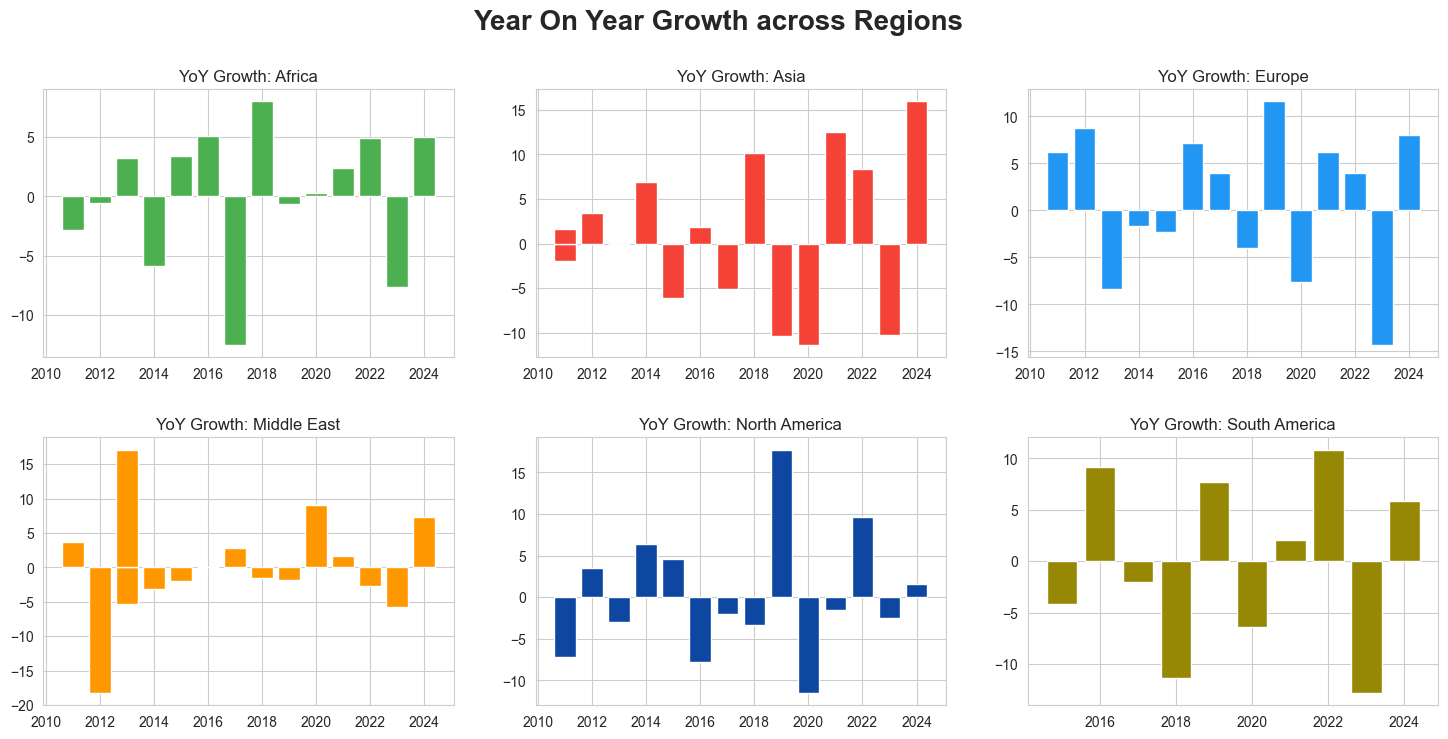

In [624]:

fig, ax = plt.subplots(2,3, figsize=(18,8))
plt.subplots_adjust(hspace=0.3)

plt.suptitle("Year On Year Growth across Regions", fontname='arial', fontweight='bold', fontsize=20)
ax[0, 0].bar(regions_years[0:14]['year'], regions_years[0:14]['percent_growth'], color='#4CAF50')
ax[0,0].set_title("YoY Growth: Africa")

ax[0, 1].bar(regions_years[14:29]['year'], regions_years[14:29]['percent_growth'], color='#F44336')
ax[0,1].set_title("YoY Growth: Asia")

ax[0, 2].bar(regions_years[29:44]['year'], regions_years[29:44]['percent_growth'], color='#2196F3')
ax[0,2].set_title("YoY Growth: Europe")

ax[1, 0].bar(regions_years[44:59]['year'], regions_years[44:59]['percent_growth'], color='#FF9800')
ax[1,0].set_title("YoY Growth: Middle East")

ax[1,1].bar(regions_years[59:74]['year'], regions_years[59:74]['percent_growth'], color='#0D47A1')
ax[1,1].set_title("YoY Growth: North America")

ax[1, 2].bar(regions_years[74:89]['year'], regions_years[74:89]['percent_growth'], color="#968704")
ax[1,2].set_title("YoY Growth: South America")


plt.show()

**Average Growth of Revenue**


In [625]:
a = regions_years[0:14]['percent_growth'].mean()
asia = regions_years[14:29]['percent_growth'].mean()
europe = regions_years[29:44]['percent_growth'].mean()
mid_east =regions_years[44:59]['percent_growth'].mean()
s_am = regions_years[59:74]['percent_growth'].mean()
n_am = regions_years[74:89]['percent_growth'].mean()

avg_reg_gr = pd.DataFrame({
    'regions': ['Africa', 'Asia', 'Europe', 'mid_east', 'South America', 'North America'],
    "avg_growth": [a, asia, europe, mid_east, s_am, n_am]
})

avg_reg_gr = avg_reg_gr.sort_values(by='avg_growth', ascending=True)

In [626]:
#calculate percentage revenue increment from 2010 to 2024

rev_change = (df.groupby(['region', 'year'])['revenue'].sum().unstack(fill_value=0))
rev_change = rev_change.rename(columns={2010: 'First_year_revenue', 2024: 'Final_Year_revenue'})
rev_change = rev_change.reset_index()


rev_change['revenue_change'] = (rev_change['Final_Year_revenue'] - rev_change['First_year_revenue'])

rev_change['percent_growth'] = ((100 * rev_change['revenue_change']) / rev_change['First_year_revenue']).round(2)


rev_change = rev_change.sort_values(by='percent_growth', ascending=True)

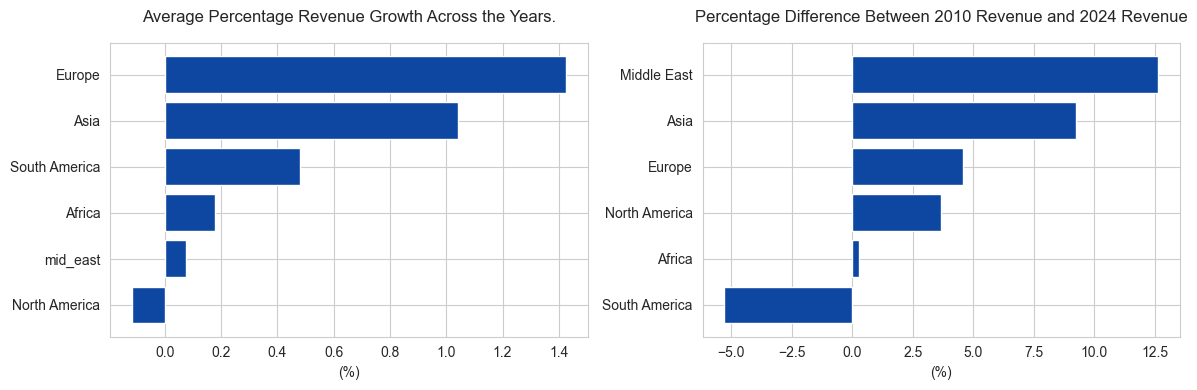

In [627]:
#plot for the two revenue growth calculations
fig, ax = plt.subplots(1,2, figsize=(12,4))

ax[0].barh(avg_reg_gr['regions'], avg_reg_gr['avg_growth'], color='#0D47A1')
ax[0].set_title("Average Percentage Revenue Growth Across the Years.", fontname='Arial', pad=15)

ax[0].set_xlabel('(%)')
ax[1].barh(rev_change['region'], rev_change['percent_growth'], color='#0D47A1')
ax[1].set_title("Percentage Difference Between 2010 Revenue and 2024 Revenue", fontname='arial', pad=15)
ax[1].set_xlabel('(%)')

plt.tight_layout()

plt.show()



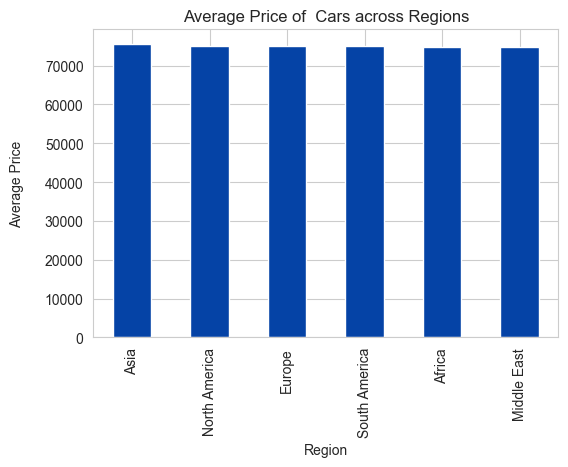

In [628]:
#Average Price of cars across regions

prices_per_model = df.groupby('region')['price_usd'].agg([
    'mean',
    'median'
]).round(2).reset_index().sort_values(by='mean', ascending=False)


prices_per_model.set_index('region')['mean'].plot(kind='bar', color=chart_color, figsize=(6,4))
plt.title('Average Price of  Cars across Regions')
plt.ylabel('Average Price', labelpad=15)
plt.xlabel('Region')
plt.show()

In [629]:
model_region_pivot = df.pivot_table(columns='model', index='region', values='sales_volume', aggfunc='sum')


model_region_pivot

model,3 Series,5 Series,7 Series,M3,M5,X1,X3,X5,X6,i3,i8
region,,,,,,,,,,,
Africa,3892595,4020702,3699471,3448709,3676252,3928136,3742723,3972541,3630167,3967283,3586673
Asia,3962239,3935629,4004066,3935579,3928390,4192289,3796115,3748736,3756074,3739218,3975942
Europe,3959930,3855515,3914409,3649697,4002667,3850033,3705572,3688138,3772519,3954257,4202401
Middle East,3889367,3708878,4080751,3832415,3936889,3818212,3745004,3946209,3777388,3840814,3750693
North America,3879277,3691777,4087259,3792785,3602546,3987029,4056192,3744219,3702034,3872237,3987274
South America,3697895,3885018,4000510,3690509,3632944,3630361,3699923,3609906,4023804,3760040,3920908


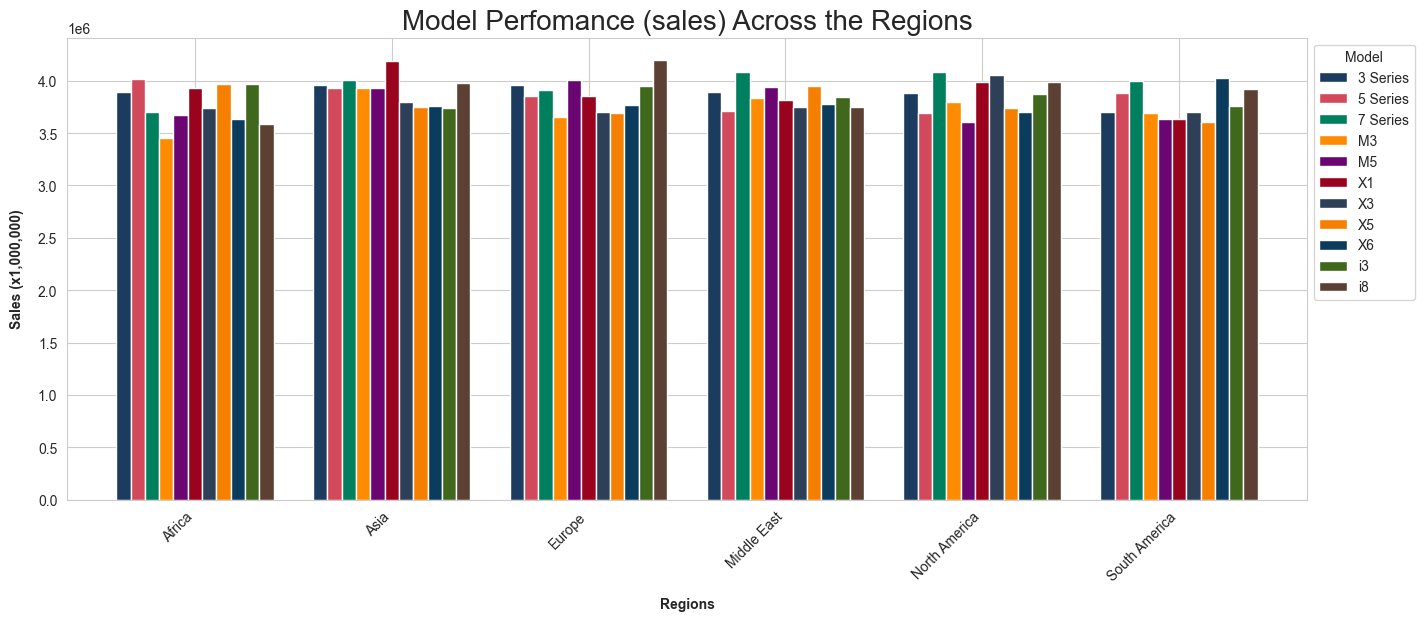

In [630]:
#Vehicle Perfomance (sales) by Regions

ax = model_region_pivot.plot(
    kind='bar',
    figsize=(16,6),
    width=0.8,
    color = (
"#1B3B5F",  "#D1495B",   "#007F5F", "#FF8C00",   "#6A0572",  "#9A031E",  
    "#2E4057", "#F77F00", "#0B3C5D", "#3F681C",  "#5C4033"   )
)

plt.ylabel("Sales (x1,000,000)", labelpad=10, fontweight='bold')
plt.xlabel("Regions", labelpad=10, fontweight='bold')
ax.legend(title='Model', bbox_to_anchor=(1, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.title('Model Perfomance (sales) Across the Regions', fontsize=20, fontname='arial')


# plt.tight_layout()

plt.show()

## FUEL TYPE ANALYSIS

*Revenue and Sales by Fuel Type*

In [631]:
fuel_type = df.groupby('fuel_type')[['sales_volume', 'revenue']].sum().reset_index()
fuel_type

,fuel_type,sales_volume,revenue
0,Diesel,62361818,4684699087721
1,Electric,63157665,4750735161530
2,Hybrid,64532097,4820671669300
3,Petrol,63324154,4756136615908


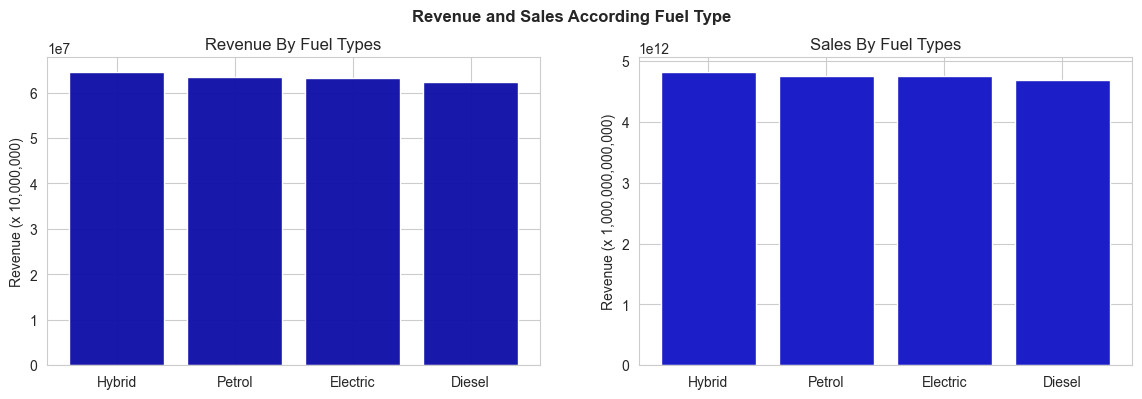

In [632]:
fig, ax = plt.subplots(1,2, figsize=(14,4))
plt.suptitle("Revenue and Sales According Fuel Type", y=1, fontweight='bold')

fuel_type = fuel_type.sort_values(by='sales_volume', ascending=False)
ax[0].bar(fuel_type['fuel_type'], fuel_type['sales_volume'], color="#1111A8F8")
ax[0].set_title('Revenue By Fuel Types')
ax[0].set_ylabel('Revenue (x 10,000,000)')


fuel_type = fuel_type.sort_values(by='revenue', ascending=False)
ax[1].bar(fuel_type['fuel_type'], fuel_type['revenue'], color="#1C1FC7")
ax[1].set_title('Sales By Fuel Types')
ax[1].set_ylabel('Revenue (x 1,000,000,000,000)')

plt.show()

*Fuel Type sales In various Regions*

In [633]:
fuel_pivot = df.pivot_table(columns='fuel_type', values='sales_volume', aggfunc='sum', index='region').reset_index()
fuel_pivot

fuel_type,region,Diesel,Electric,Hybrid,Petrol
0,Africa,10211670,10329085,10486034,10538463
1,Asia,10492033,10596850,11422396,10462998
2,Europe,10406133,10590064,10825662,10733279
3,Middle East,10491957,10395195,10627320,10812148
4,North America,10259904,10861198,10808682,10472845
5,South America,10500121,10385273,10362003,10304421


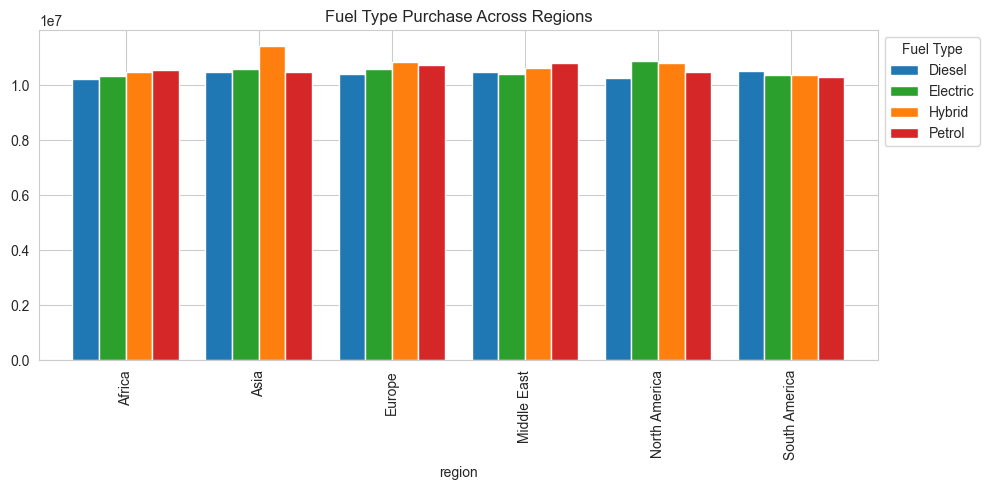

In [634]:
ax = fuel_pivot.set_index('region').plot(kind='bar', figsize=(10,5), width=0.8, color=( "#1f77b4", "#2ca02c",  "#ff7f0e", "#d62728"))

ax.legend(title='Fuel Type', bbox_to_anchor=(1, 1), loc='upper left')
plt.title("Fuel Type Purchase Across Regions")
plt.tight_layout()
plt.show()


**Transmission Type Analysis**

*sales Volume by transmision types*

In [ ]:
#Group by regions
txns_pivot = df.pivot_table(columns='transmission', values='sales_volume', aggfunc='sum', index='region').reset_index()
txns_pivot

transmission,region,Automatic,Manual
0,Africa,20637260,20927992
1,Asia,21646739,21327538
2,Europe,21086212,21468926
3,Middle East,21025867,21300753
4,North America,21329746,21072883
5,South America,20287833,21263985


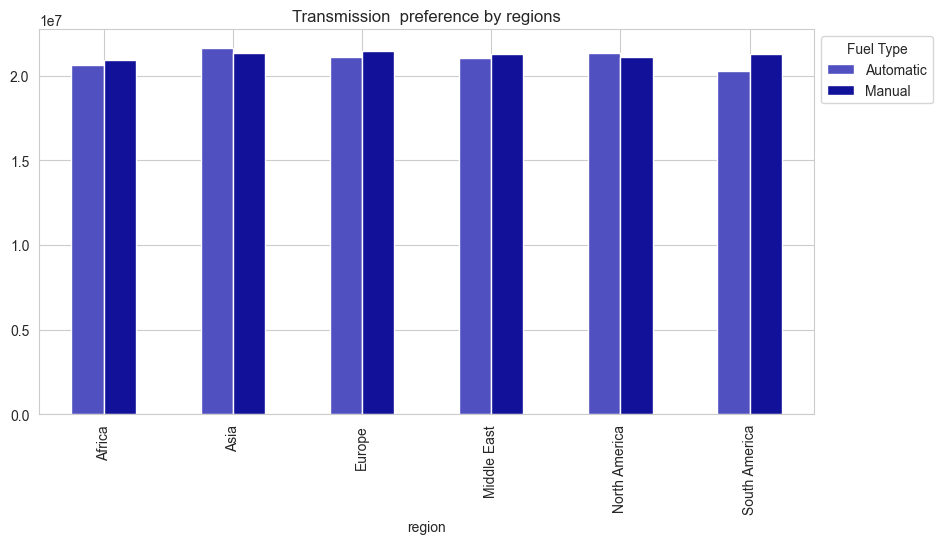

In [636]:
ax = txns_pivot.set_index('region').plot(kind='bar', figsize=(10,5), color=["#5050C1", '#111199'])

ax.legend(title='Fuel Type', bbox_to_anchor=(1, 1), loc='upper left')
plt.title('Transmission  preference by regions')

plt.show()

**Engine Size**

In [637]:
#create a Bucket for the engine sizes

df['engine_groups'] = pd.cut(
    df['engine_size_l'],
    bins=[0, 1.9,2.9,3.9,4.9,5],
    labels= [
        '1.0 - 1.9L',
        '2.0 - 2.9L',
        '3.0 - 3.9L',
        '4.0 - 4.9L',
        '5L above'
    ]
)

In [650]:
engine_grps = df.groupby(['engine_groups'])[['sales_volume', 'revenue']].sum().reset_index()
engine_grps = engine_grps.sort_values(by='sales_volume', ascending=False)
engine_grps

,engine_groups,sales_volume,revenue
2,3.0 - 3.9L,72771536,5479345744603
1,2.0 - 2.9L,72381530,5431320055385
3,4.0 - 4.9L,71741436,5384830610978
0,1.0 - 1.9L,32837640,2452546501875
4,5L above,3643592,264199621618


In [658]:
engine_grps_regions = df.groupby(['region','engine_groups'])['sales_volume'].sum().unstack(fill_value=0).reset_index()

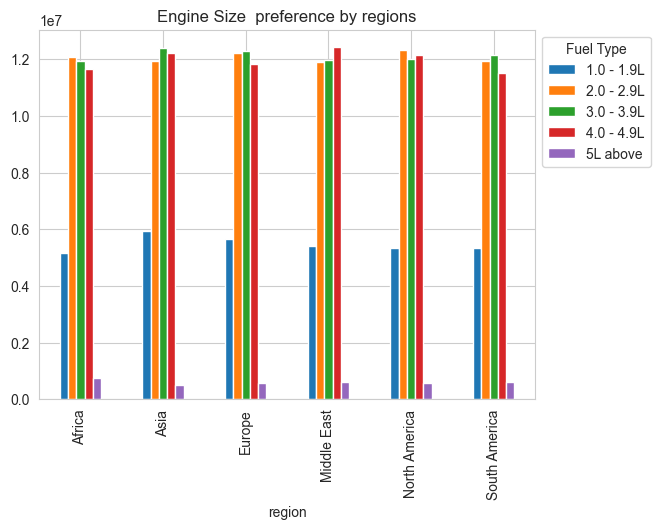

In [664]:
ax = engine_grps_regions.set_index('region').plot(
    kind='bar'
)

ax.legend(title='Fuel Type', bbox_to_anchor=(1, 1), loc='upper left')

plt.title('Engine Size  preference by regions')
plt.Figure(figsize=(8,4))

plt.show()


**Mileage, Average Price and Sales volume**

In [666]:
# Create Bins for the mileage groups

df['mileage_km_grps'] = pd.cut(
    df['mileage_km'],
    bins=[0, 50000, 100000, 900000],
    labels=[
        'Low Mileage(≤ 50,000km)',
        'medium Mileage(50,001 - 100,000 km)',
        'High Mileage(100,000 km +)'
    ]
)

In [680]:

miles_price = df.groupby('mileage_km_grps').agg(
    Avg_Price=('price_usd', 'mean'),
    Sales=('sales_volume', 'sum')
).reset_index()

miles_price['Avg_Price'] = miles_price['Avg_Price'].round(2)

miles_price


,mileage_km_grps,Avg_Price,Sales
0,"Low Mileage(≤ 50,000km)",75057.42,62924060
1,"medium Mileage(50,001 - 100,000 km)",75253.47,63239241
2,"High Mileage(100,000 km +)",74914.59,127212433


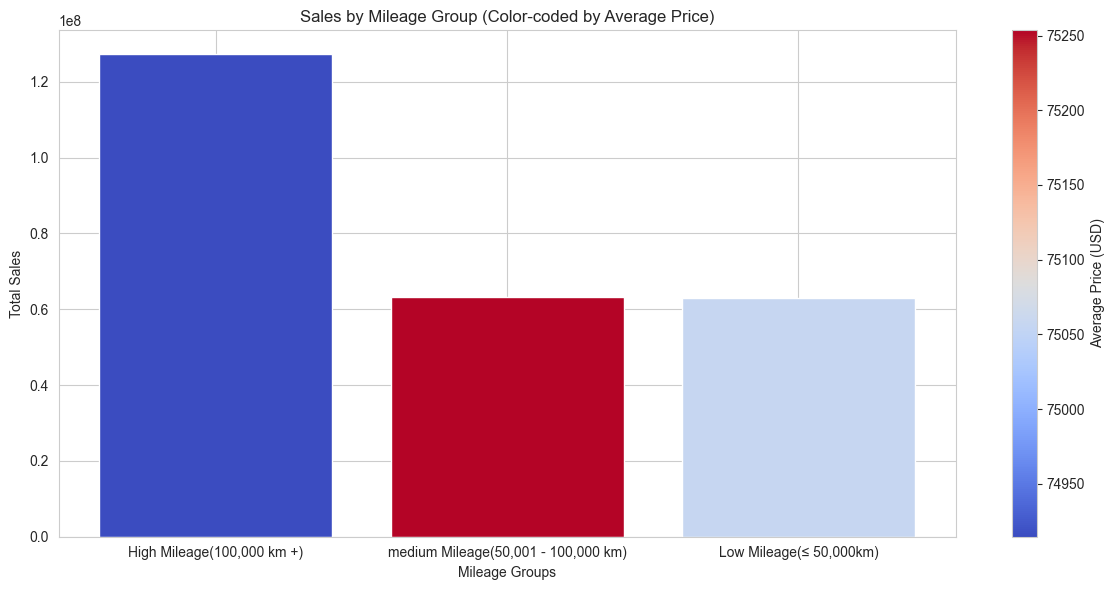

In [685]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Sort by Sales
miles_price_sorted = miles_price.sort_values(by='Sales', ascending=False)

# Normalize price for colors
norm = mpl.colors.Normalize(
    vmin=miles_price_sorted['Avg_Price'].min(),
    vmax=miles_price_sorted['Avg_Price'].max()
)

cmap = mpl.cm.coolwarm
colors = cmap(norm(miles_price_sorted['Avg_Price']))

# Create figure and axis
fig, ax = plt.subplots(figsize=(12,6))

# Plot bars
bars = ax.bar(
    miles_price_sorted['mileage_km_grps'],
    miles_price_sorted['Sales'],
    color=colors
)

# Labels
ax.set_xlabel('Mileage Groups')
ax.set_ylabel('Total Sales')
ax.set_title('Sales by Mileage Group (Color-coded by Average Price)')

# Rotate labels
# plt.xticks(rotation=5, ha='right')

# Create colorbar properly
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax)   # 🔥 FIX IS HERE
cbar.set_label('Average Price (USD)')

plt.tight_layout()
plt.show()